In [5]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/68.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/68.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/68.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/68.3 kB ? eta -:--:--
   ------------------------------------ --- 61.4/68.3 kB ? eta -:--:--
   ---------------------------------------- 68.3/68.3 kB 1.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
path=kagglehub.dataset_download('sulianova/cardiovascular-disease-dataset')
print('Path to dataset files:',path)

Path to dataset files: C:\Users\metaking\.cache\kagglehub\datasets\sulianova\cardiovascular-disease-dataset\versions\1


In [4]:
file_name='cardio_train.csv'
file_path=os.path.join(path,file_name)

In [5]:
data=pd.read_csv(file_path,sep=';')
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [6]:
data.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [7]:
data.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [8]:
data['age']=(data['age']/365).astype(int)
data=data.drop(columns=['id'])
data.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [9]:
data['BMI'] =data['weight']/((data['height']/100)** 2)

In [72]:
def bmi_category(a):
    if a <= 18.5:
        return 'Underweight'
    elif 18.5 <a <= 25:
        return 'Normal'
    elif 25<a <= 30:
        return 'Overweight'
    else:
        return 'Obese'

In [73]:
data['BMI_cat'] = data['BMI'].apply(bmi_category)
data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,BMI_cat,high_ap_hi,high_ap_lo
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,Normal,0,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,Obese,0,0
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,Normal,0,0
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,Overweight,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,Normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,2,168,76.0,120,80,1,1,1,0,1,0,26.927438,Overweight,0,0
69996,61,1,158,126.0,140,90,2,2,0,0,1,1,50.472681,Obese,0,0
69997,52,2,183,105.0,180,90,3,1,0,1,0,1,31.353579,Obese,1,0
69998,61,1,163,72.0,135,80,1,2,0,0,0,1,27.099251,Overweight,0,0


In [74]:
data= data[(data['BMI'] >= 10) & (data['BMI'] <= 60)]
data= data[(data['ap_hi'] >= 50) & (data['ap_hi'] <= 250)]
data= data[(data['ap_lo'] >= 30) & (data['ap_lo'] <= 150)]

In [39]:
numeric_columns=['age','height','weight','ap_hi','ap_lo','BMI']
numeric_summary=data[numeric_columns].describe().round(1)
numeric_summary

,age,height,weight,ap_hi,ap_lo,BMI
count,68695.0,68695.0,68695.0,68695.0,68695.0,68695.0
mean,52.8,164.4,74.1,126.6,81.4,27.4
std,6.8,7.9,14.2,16.7,9.6,5.2
min,29.0,100.0,28.0,60.0,30.0,10.7
25%,48.0,159.0,65.0,120.0,80.0,23.9
50%,53.0,165.0,72.0,120.0,80.0,26.3
75%,58.0,170.0,82.0,140.0,90.0,30.1
max,64.0,250.0,200.0,240.0,150.0,60.0


In [75]:
print("\nBMI category counts:\n", data['BMI_cat'].value_counts())


BMI category counts:
 BMI_cat
Normal         25463
Overweight     24653
Obese          17941
Underweight      638
Name: count, dtype: int64


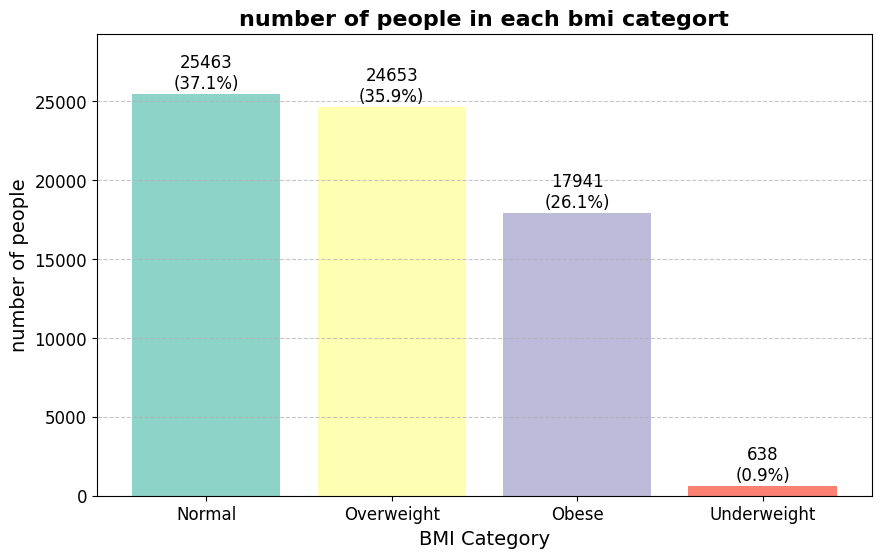

In [76]:
bmi_counts=data['BMI_cat'].value_counts()

bmi_percent = bmi_counts / bmi_counts.sum() * 100

plt.figure(figsize=(10,6))
bars = plt.bar(bmi_counts.index, bmi_counts.values,
color=plt.cm.Set3.colors)

for bar, count, perc in zip(bars, bmi_counts.values, bmi_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{count}\n({perc:.1f}%)',
    ha='center', va='bottom', fontsize=12)


plt.title('number of people in each bmi categort', fontsize=16, fontweight='bold')
plt.xlabel('BMI Category', fontsize=14)
plt.ylabel('number of people', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, max(bmi_counts.values)*1.15) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

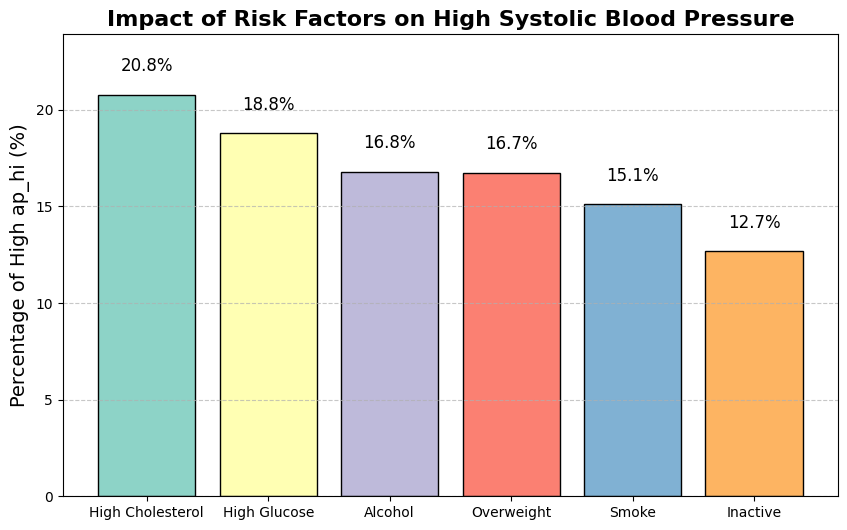

In [41]:
#فشار سیستولیک بالا
data['high_ap_hi'] = (data['ap_hi'] > 140).astype(int)

risk_factors = {
'Overweight': data['BMI'] >= 25,
'Inactive': data['active'] == 0,
'Alcohol': data['alco'] == 1,
'Smoke': data['smoke'] == 1,
'High Glucose': data['gluc'] > 1,
'High Cholesterol': data['cholesterol'] > 1
}

impact = {}
for name, mask in risk_factors.items():
    impact[name] = (data.loc[mask, 'high_ap_hi'].sum() / mask.sum()) * 100

impact = dict(sorted(impact.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10,6))
bars = plt.bar(impact.keys(), impact.values(), color=plt.cm.Set3.colors, edgecolor='black')

for bar, val in zip(bars, impact.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha='center', va='bottom', fontsize=12)

plt.title('Impact of Risk Factors on High Systolic Blood Pressure', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of High ap_hi (%)', fontsize=14)
plt.ylim(0, max(impact.values())*1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

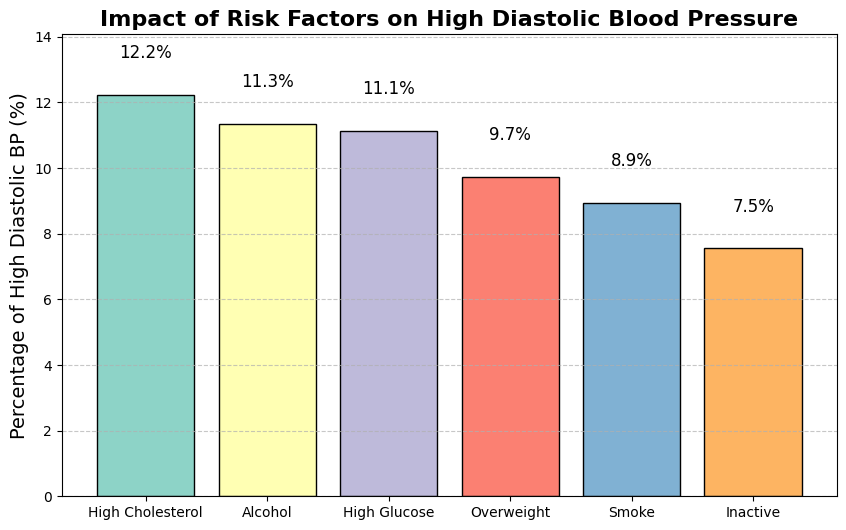

In [42]:
#  فشار دیاستولیک بالا
data['high_ap_lo'] = (data['ap_lo'] > 90).astype(int)

risk_factors = {
'Overweight': data['BMI'] >= 25,
'Inactive': data['active'] == 0,
'Alcohol': data['alco'] == 1,
'Smoke': data['smoke'] == 1,
'High Glucose': data['gluc'] > 1,
'High Cholesterol': data['cholesterol'] > 1
}

impact_diastolic = {}
for name, mask in risk_factors.items():
    impact_diastolic[name] = (data.loc[mask, 'high_ap_lo'].sum() / mask.sum()) * 100

impact_diastolic = dict(sorted(impact_diastolic.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10,6))
bars = plt.bar(impact_diastolic.keys(), impact_diastolic.values(), color=plt.cm.Set3.colors, edgecolor='black')

for bar, val in zip(bars, impact_diastolic.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha='center', va='bottom', fontsize=12)

plt.title('Impact of Risk Factors on High Diastolic Blood Pressure', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of High Diastolic BP (%)', fontsize=14)
plt.ylim(0, max(impact_diastolic.values())*1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

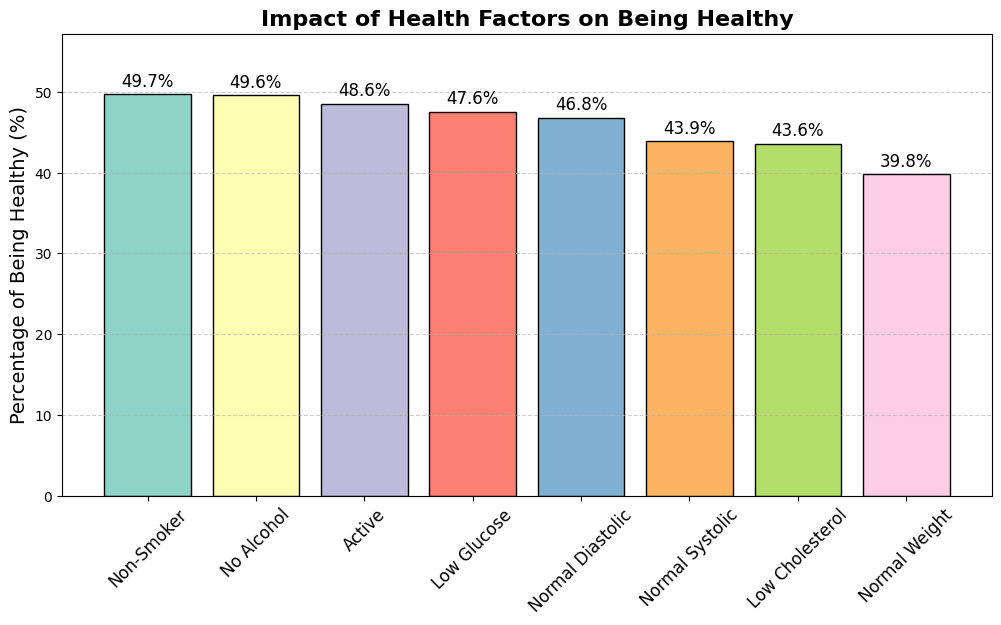

In [43]:
health_factors = {
'Normal Weight': data['BMI_cat'] == 'Normal',
'Normal Systolic': data['ap_hi'] <= 140,
'Normal Diastolic': data['ap_lo'] <= 90,
'Low Cholesterol': data['cholesterol'] == 1,
'Low Glucose': data['gluc'] == 1,
'Non-Smoker': data['smoke'] == 0,
'No Alcohol': data['alco'] == 0,
'Active': data['active'] == 1
}

health_impact = {}
for name, mask in health_factors.items():
    health_impact[name] = (data.loc[mask, 'cardio'].sum() / mask.sum()) * 100

health_impact = dict(sorted(health_impact.items(), key=lambda x: x[1], reverse=True))


plt.figure(figsize=(12,6))
bars = plt.bar(health_impact.keys(), health_impact.values(),
color=plt.cm.Set3.colors, edgecolor='black')

for bar, val in zip(bars, health_impact.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1,
    f"{val:.1f}%", ha='center', fontsize=12)

plt.title("Impact of Health Factors on Being Healthy", fontsize=16, fontweight='bold')
plt.ylabel("Percentage of Being Healthy (%)", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.ylim(0, max(health_impact.values()) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

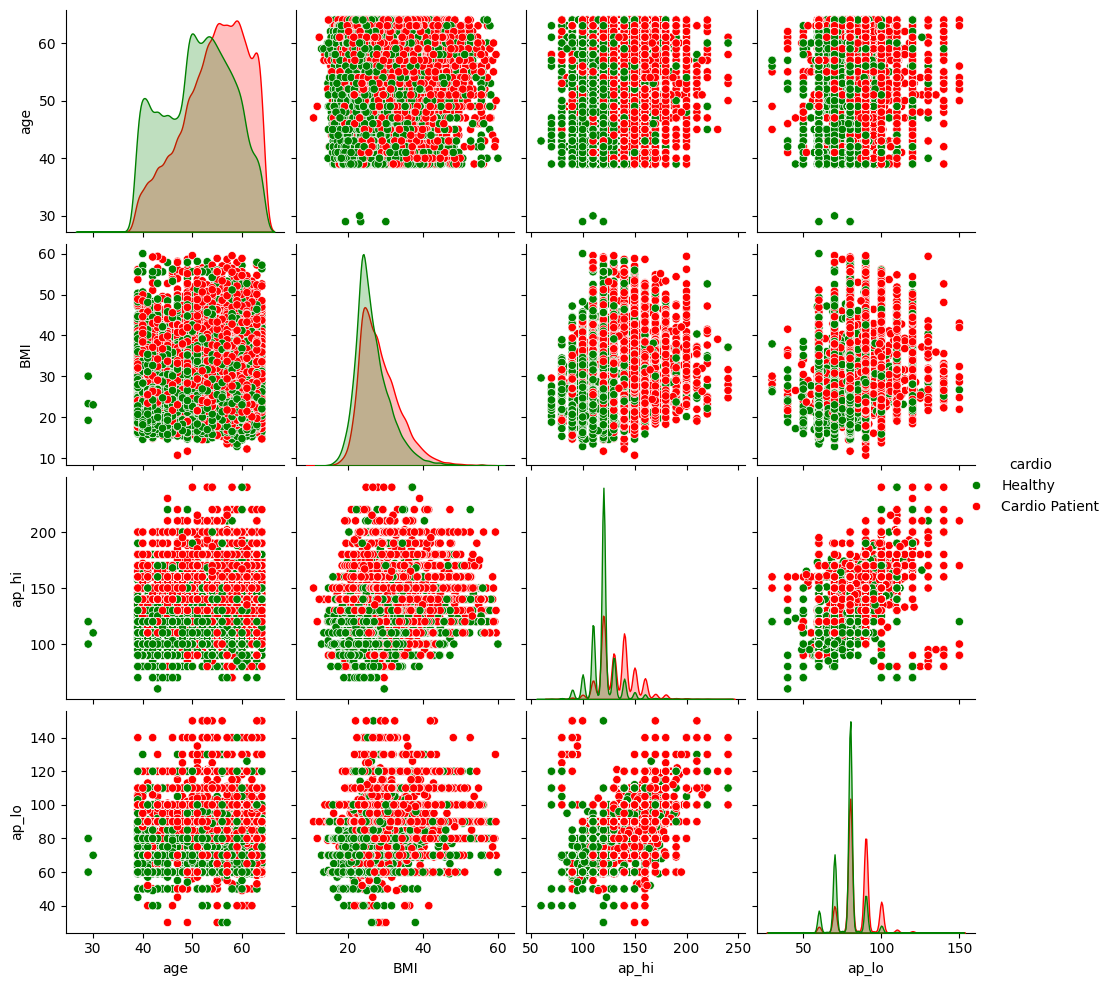

In [70]:
plot = sns.pairplot(
data,
vars=['age','BMI','ap_hi','ap_lo'],
hue='cardio',
palette={0:'green', 1:'red'}
)

legend = plot._legend
legend.texts[0].set_text("Healthy")
legend.texts[1].set_text("Cardio Patient")

legend.set_bbox_to_anchor((1.05, 0.5))

plt.show()

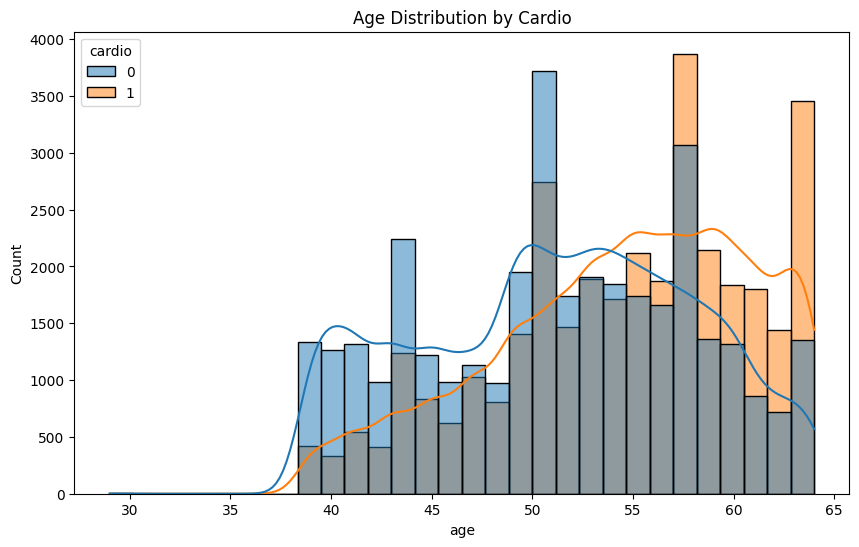

In [49]:
plt.figure(figsize=(10,6))
sns.histplot(data=data, x='age', hue='cardio', bins=30, kde=True)
plt.title("Age Distribution by Cardio")
plt.show()

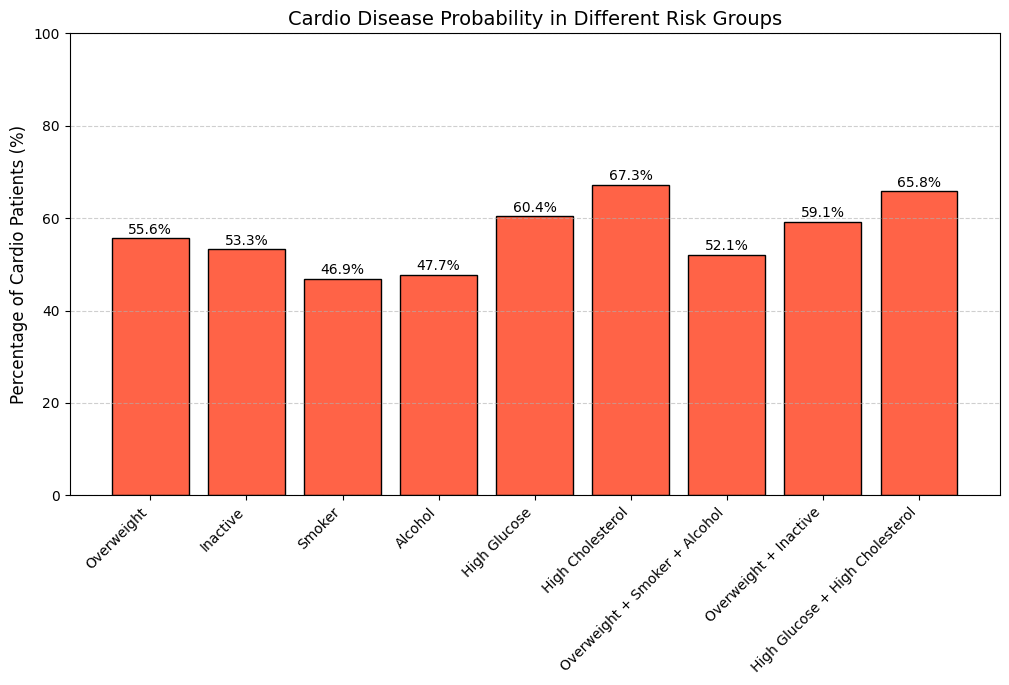

In [50]:
groups = {
'Overweight': (data['BMI'] >= 25),
'Inactive': (data['active'] == 0),
'Smoker': (data['smoke'] == 1),
'Alcohol': (data['alco'] == 1),
'High Glucose': (data['gluc'] > 1),
'High Cholesterol': (data['cholesterol'] > 1),
'Overweight + Smoker + Alcohol': (data['BMI'] >= 25) & (data['smoke'] == 1) & (data['alco'] == 1),
'Overweight + Inactive': (data['BMI'] >= 25) & (data['active'] == 0),
'High Glucose + High Cholesterol': (data['gluc'] > 1) & (data['cholesterol'] > 1)
}

percentages = []
for name, mask in groups.items():
    total = mask.sum()
    cardio_count = data.loc[mask, 'cardio'].sum()
    percentages.append((cardio_count / total) * 100 if total > 0 else 0)

plt.figure(figsize=(12,6))
bars = plt.bar(groups.keys(), percentages, color='tomato', edgecolor='black')

for bar, val in zip(bars, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', fontsize=10)

plt.ylim(0,100)
plt.ylabel('Percentage of Cardio Patients (%)', fontsize=12)
plt.title('Cardio Disease Probability in Different Risk Groups', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

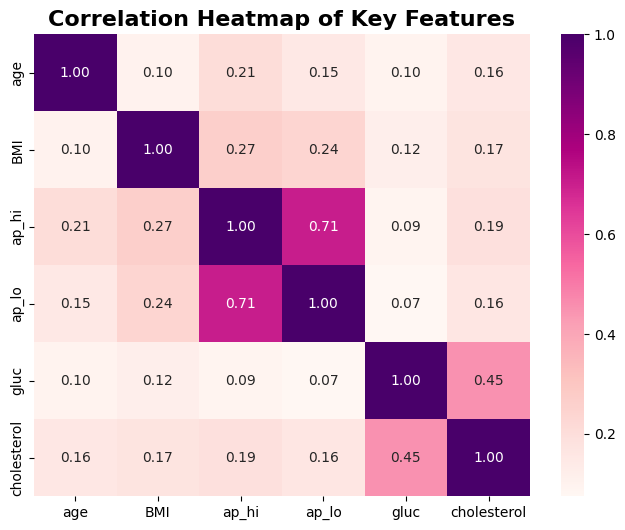

In [61]:
important_cols = ['age', 'BMI', 'ap_hi', 'ap_lo', 'gluc', 'cholesterol']
corr_matrix = data[important_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdPu")
plt.title("Correlation Heatmap of Key Features", fontsize=16, fontweight='bold')
plt.show()

In [52]:
data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,BMI_cat,high_ap_hi,high_ap_lo
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,Normal,0,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,Obese,0,0
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,Normal,0,0
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,Overweight,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,Normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,2,168,76.0,120,80,1,1,1,0,1,0,26.927438,Overweight,0,0
69996,61,1,158,126.0,140,90,2,2,0,0,1,1,50.472681,Obese,0,0
69997,52,2,183,105.0,180,90,3,1,0,1,0,1,31.353579,Obese,1,0
69998,61,1,163,72.0,135,80,1,2,0,0,0,1,27.099251,Overweight,0,0


In [53]:
x=data.drop(columns=['BMI_cat','high_ap_hi','high_ap_lo','height','weight','cardio'])
y=data['cardio']

In [54]:
xtrain , xtest , ytrain , ytest=train_test_split(x,y , test_size=0.3, random_state=42)

In [55]:
scale=StandardScaler()
xtrain=scale.fit_transform(xtrain)
xtest=scale.transform(xtest)

In [62]:
p_grid={'penalty':['l1','l2'],'C':[0.01,0.1,1],'solver':['liblinear','saga'],'max_iter':[100,300]}
lr=LogisticRegression()
lr_cv=GridSearchCV(estimator=lr,param_grid=p_grid,cv=5,n_jobs=-1,verbose=2)
lr_cv.fit(xtrain,ytrain)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1], 'max_iter': [100, 300],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             verbose=2)

In [63]:
print(lr_cv.best_params_)
print(lr_cv.best_score_)

{'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
0.7277169858004923


In [64]:
lr=LogisticRegression(C= 0.1, max_iter=100, penalty= 'l2', solver='liblinear')
lr.fit(xtrain,ytrain)
ypred_lr=lr.predict(xtest)
acc_lr=metrics.accuracy_score(ytest,ypred_lr)
acc_lr

0.7263816779077102

In [77]:
data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,BMI_cat,high_ap_hi,high_ap_lo
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,Normal,0,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,Obese,0,0
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,Normal,0,0
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,Overweight,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,Normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,2,168,76.0,120,80,1,1,1,0,1,0,26.927438,Overweight,0,0
69996,61,1,158,126.0,140,90,2,2,0,0,1,1,50.472681,Obese,0,0
69997,52,2,183,105.0,180,90,3,1,0,1,0,1,31.353579,Obese,1,0
69998,61,1,163,72.0,135,80,1,2,0,0,0,1,27.099251,Overweight,0,0


In [68]:
newdata={'age':[50], 'gender':[2],'ap_hi':[110], 'ap_lo':[80],'cholesterol':[1], 'gluc':[1], 'smoke':[0], 'alco':[0],'active':[1], 'BMI':[21.967120]}
new_data=pd.DataFrame(newdata)
new_data=scale.transform(new_data)
predict=lr.predict(new_data)
print(f'predicted cardio:{predict}') 

predicted cardio:[0]


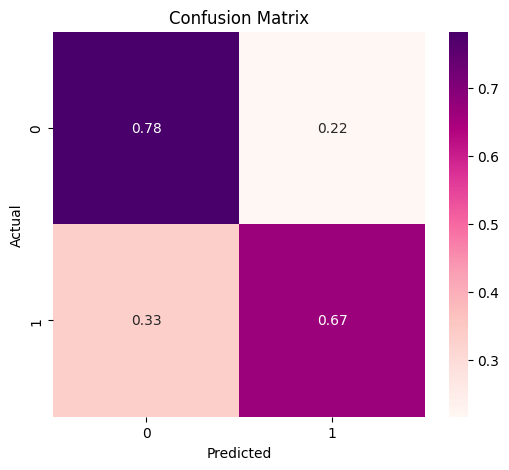

In [67]:
cm = confusion_matrix(ytest, ypred_lr, normalize='true')

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='.2f' ,cmap="RdPu")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()